In [2]:
import numpy as np
import gudhi as gd
import pandas as pd
from sklearn import manifold
from pylab import *
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.tri as mtri
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

CTA stations plot and persistence diagram

c:\Users\Adamc\anaconda3\Lib\site-packages\gudhi\persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


<Axes: title={'center': 'Persistence density'}, xlabel='Birth', ylabel='Death'>

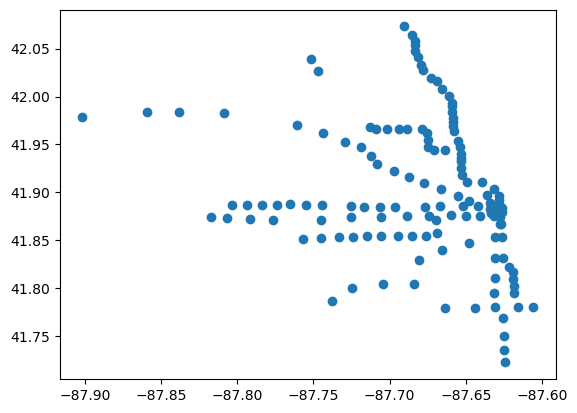

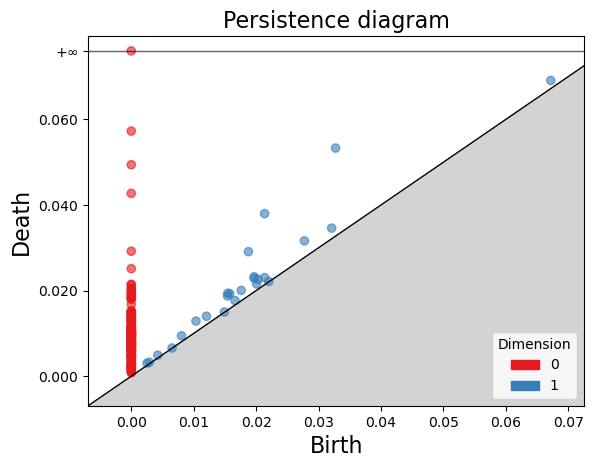

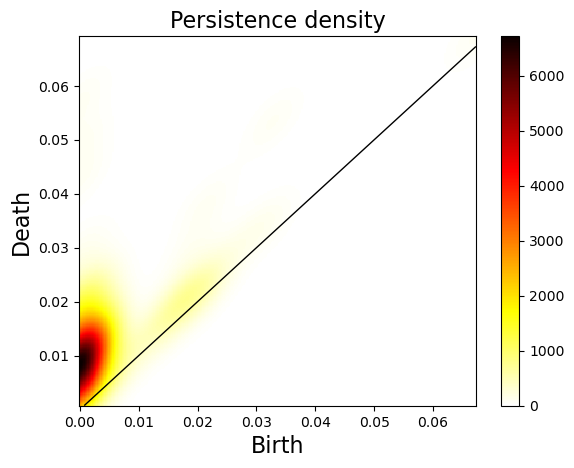

In [3]:

stations = np.loadtxt('data/points/CTA_L_X_Y.txt', delimiter=",",skiprows=1)


sta_rips_complex = gd.RipsComplex(points=stations)
sta_tree = sta_rips_complex.create_simplex_tree(max_dimension=2)

barcodes_sta=sta_tree.persistence()

sta_tree.compute_persistence()
plt.scatter(stations[:,0], stations[:,1])
gd.plot_persistence_diagram(barcodes_sta)
gd.plot_persistence_density(barcodes_sta)

Finding these transit deserts

[[0.                inf]
 [0.         0.0572656 ]
 [0.         0.0494054 ]
 [0.         0.04271244]
 [0.         0.02919763]
 [0.         0.02511843]
 [0.         0.02144339]
 [0.         0.0213762 ]
 [0.         0.02061729]
 [0.         0.02025845]
 [0.         0.01982186]
 [0.         0.01954771]
 [0.         0.01932638]
 [0.         0.01893774]
 [0.         0.01853327]
 [0.         0.0182845 ]
 [0.         0.01814675]
 [0.         0.01796661]
 [0.         0.01677932]
 [0.         0.01530127]
 [0.         0.01504714]
 [0.         0.01503857]
 [0.         0.01491883]
 [0.         0.01488488]
 [0.         0.01486715]
 [0.         0.01448902]
 [0.         0.01428762]
 [0.         0.01401521]
 [0.         0.0138841 ]
 [0.         0.01366067]
 [0.         0.01354734]
 [0.         0.01342665]
 [0.         0.01322764]
 [0.         0.01310952]
 [0.         0.01299963]
 [0.         0.01284733]
 [0.         0.01266933]
 [0.         0.01225183]
 [0.         0.01221559]
 [0.         0.01181924]


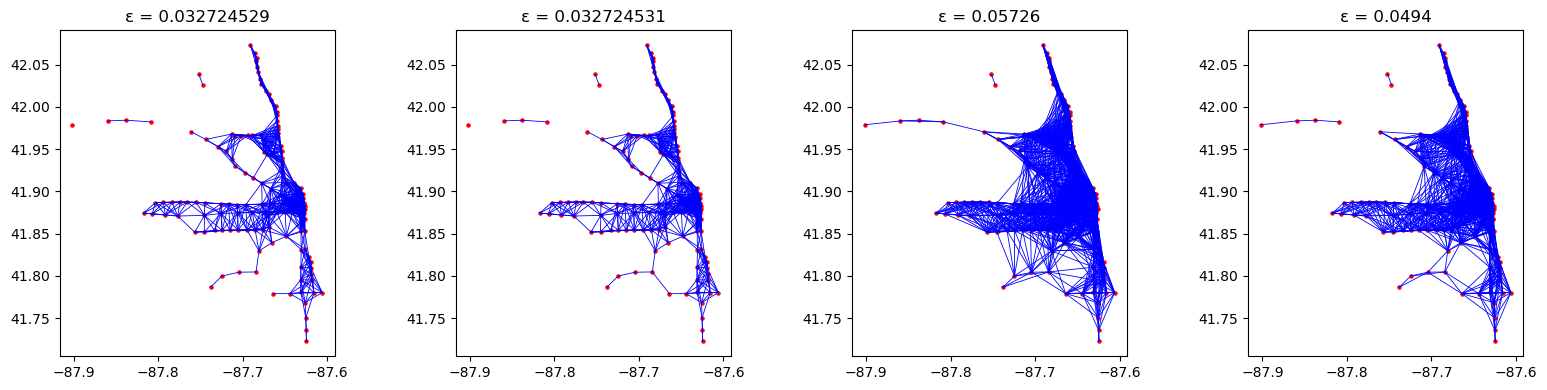

In [4]:
Ista1 = sta_tree.persistence_intervals_in_dimension(1)
lifetimes1 = Ista1[:,1] - Ista1[:,0]
order = np.argsort(lifetimes1)[::-1]
Ista_sorted1 = Ista1[order]
#print(Ista_sorted1)

I0sta = sta_tree.persistence_intervals_in_dimension(0)
lifetimes0 = I0sta[:,1]
order = np.argsort(lifetimes0)[::-1]
Ista_sorted0 = I0sta[order]
print(Ista_sorted0)

epsilons = [0.032724529, 0.032724531, 0.05726, 0.0494]

fig, axes = plt.subplots(1, 4, figsize=(16,4))

for ax, epsilon in zip(axes, epsilons):

    edges = []
    triangles = []

    for simplex, filt in sta_tree.get_skeleton(2):
        if filt <= epsilon:
            if len(simplex) == 2:
                edges.append(simplex)

    edges = np.array(edges)

    for e in edges:
        x = stations[e,0]
        y = stations[e,1]
        ax.plot(x, y, color='blue', lw=0.6)

    ax.scatter(stations[:,0], stations[:,1], color='red', s=5)
    ax.set_aspect('equal')
    ax.set_title(f"ε = {epsilon}")

plt.tight_layout()
plt.show()

# [0.03272453 0.0533043 ]
# [0.02135608 0.0379751 ]
# [0.01876452 0.02909447]